In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df = pd.read_csv(r'C:\Users\Marcus\Desktop\python pandas\superstore_data\version_control\superstore_clean.csv')
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,City,State,...,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit,Shipping Cost,Order Priority
0,31518,CA-2012-169397,2012-12-24,2013-01-09,First Class,JB-15925,Joni Blumstein,Consumer,Dublin,Ohio,...,OFF-BI-10002852,Office Supplies,Binders,Ibico Standard Transparent Covers,19.7760,4,0.70,-13.84,0.79,Medium
1,6224,US-2011-144729,2011-07-21,2011-08-07,First Class,SS-20140,Saphhira Shifley,Corporate,San Miguelito,Panama,...,OFF-FA-10002247,Office Supplies,Fasteners,"Oic Paper Clips, Bulk Pack",11.5440,2,0.40,-5.22,0.97,Medium
2,15333,IT-2014-4749412,2014-09-18,2014-09-28,Standard Class,MB-18085,Mick Brown,Unknown,Birmingham,England,...,OFF-AR-10003113,Office Supplies,Art,"Binney & Smith Pens, Blue",29.8500,5,0.50,-4.80,3.71,Medium
3,49259,NI-2013-4420,2013-04-10,2013-10-26,Standard Class,MP-7965,Michael Paige,Corporate,Lagos,Lagos,...,OFF-AVE-10004512,Office Supplies,Binders,"Avery Hole Reinforcements, Economy",1.3230,1,0.70,-3.09,0.06,Medium
4,24199,IN-2014-14423,2014-10-29,2014-11-27,First Class,DL-12925,Daniel Lacy,Consumer,Kendari,Sulawesi Tenggara,...,FUR-FU-10002362,Furnitures,Furnishings,"Advantus Door Stop, Black",131.4876,4,0.27,25.17,0.00,High
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
51365,17526,ES-2014-2057259,2014-08-02,2014-05-19,First Class,PB-19150,Philip Brown,Consumer,Cagnes-Sur-Mer,Provence-Alpes-Cote D'Azur,...,OFF-PA-10002616,Office Supplies,Paper,"Green Bar Parchment Paper, Multicolor",108.5400,6,0.00,34.56,11.76,Medium
51366,36055,CA-2011-121573,2011-11-03,2011-08-07,Standard Class,SG-20605,Speros Goranitis,Consumer,New York City,New York,...,TEC-PH-10000984,Technology,Phones,Panasonic Kx-Tg9471B,783.9600,4,0.00,219.51,64.42,High
51367,43576,TU-2011-9190,2011-12-23,2012-01-11,Second Class,CM-1830,Cari Macintyre,Corporate,Corum,Corum,...,OFF-KIT-10002357,Office Supplies,Appliances,"Kitchenaid Blender, White",39.8400,1,0.60,-12.96,5.84,Medium
51368,22403,IN-2013-35388,2013-08-07,2013-11-19,Standard Class,IM-15055,Unknown,Consumer,Jakarta,Jakarta,...,OFF-AR-10000058,Office Supplies,Art,"Stanley Canvas, Water Color",38.4345,1,0.27,3.66,2.96,Medium


In [6]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 51370 entries, 0 to 51369
Data columns (total 24 columns):
 #   Column          Non-Null Count  Dtype         
---  ------          --------------  -----         
 0   Row ID          51370 non-null  int64         
 1   Order ID        51370 non-null  str           
 2   Order Date      51370 non-null  datetime64[us]
 3   Ship Date       51370 non-null  datetime64[us]
 4   Ship Mode       51370 non-null  str           
 5   Customer ID     51370 non-null  str           
 6   Customer Name   51336 non-null  str           
 7   Segment         51370 non-null  str           
 8   City            51351 non-null  str           
 9   State           51339 non-null  str           
 10  Country         51370 non-null  str           
 11  Postal Code     51370 non-null  int64         
 12  Market          51370 non-null  str           
 13  Region          51370 non-null  str           
 14  Product ID      51370 non-null  str           
 15  Category     

In [4]:
# What is the average fulfillment lag (days between Order Date and Ship Date) across different Ship Modes?

In [5]:
df['Order Date'] = pd.to_datetime(df['Order Date'])
df['Ship Date'] = pd.to_datetime(df['Ship Date'])

In [12]:
order_ship_date = df[['Ship Mode','Order Date','Ship Date']]
order_ship_date

,Ship Mode,Order Date,Ship Date
0,First Class,2012-12-24,2013-01-09
1,First Class,2011-07-21,2011-08-07
2,Standard Class,2014-09-18,2014-09-28
3,Standard Class,2013-04-10,2013-10-26
4,First Class,2014-10-29,2014-11-27
...,...,...,...
51365,First Class,2014-08-02,2014-05-19
51366,Standard Class,2011-11-03,2011-08-07
51367,Second Class,2011-12-23,2012-01-11
51368,Standard Class,2013-08-07,2013-11-19


In [13]:
order_ship_date['order_processing_time_days'] = order_ship_date['Ship Date'] - order_ship_date['Order Date']
order_ship_date

,Ship Mode,Order Date,Ship Date,order_processing_time_days
0,First Class,2012-12-24,2013-01-09,16 days
1,First Class,2011-07-21,2011-08-07,17 days
2,Standard Class,2014-09-18,2014-09-28,10 days
3,Standard Class,2013-04-10,2013-10-26,199 days
4,First Class,2014-10-29,2014-11-27,29 days
...,...,...,...,...
51365,First Class,2014-08-02,2014-05-19,-75 days
51366,Standard Class,2011-11-03,2011-08-07,-88 days
51367,Second Class,2011-12-23,2012-01-11,19 days
51368,Standard Class,2013-08-07,2013-11-19,104 days


In [15]:
order_ship_date['order_processing_time_days'] = order_ship_date['order_processing_time_days'].astype(str)

In [17]:
order_ship_date['order_processing_time_days'] = order_ship_date['order_processing_time_days'].str.replace('days','')

In [19]:
order_ship_date['order_processing_time_days']=order_ship_date['order_processing_time_days'].str.replace('-','')

In [20]:
order_ship_date['order_processing_time_days']=order_ship_date['order_processing_time_days'].str.strip()

In [23]:
order_ship_date['order_processing_time_days'] = order_ship_date['order_processing_time_days'].astype(int)

In [24]:
order_ship_date

,Ship Mode,Order Date,Ship Date,order_processing_time_days
0,First Class,2012-12-24,2013-01-09,16
1,First Class,2011-07-21,2011-08-07,17
2,Standard Class,2014-09-18,2014-09-28,10
3,Standard Class,2013-04-10,2013-10-26,199
4,First Class,2014-10-29,2014-11-27,29
...,...,...,...,...
51365,First Class,2014-08-02,2014-05-19,75
51366,Standard Class,2011-11-03,2011-08-07,88
51367,Second Class,2011-12-23,2012-01-11,19
51368,Standard Class,2013-08-07,2013-11-19,104


In [25]:
# What is the average fulfillment lag (days between Order Date and Ship Date) across different Ship Modes?

In [29]:
avg_fulfillment_lag = order_ship_date.groupby(order_ship_date['Ship Mode'])[['order_processing_time_days']].mean().astype(int)

In [31]:
avg_fulfillment_lag.reset_index(inplace=True)
avg_fulfillment_lag

,Ship Mode,order_processing_time_days
0,First Class,261
1,Same Day,0
2,Second Class,250
3,Standard Class,258
4,Unknown,299


In [65]:
avg_fulfillment_lag['Ship Mode'] = avg_fulfillment_lag['Ship Mode'].replace('Unknown','Other')

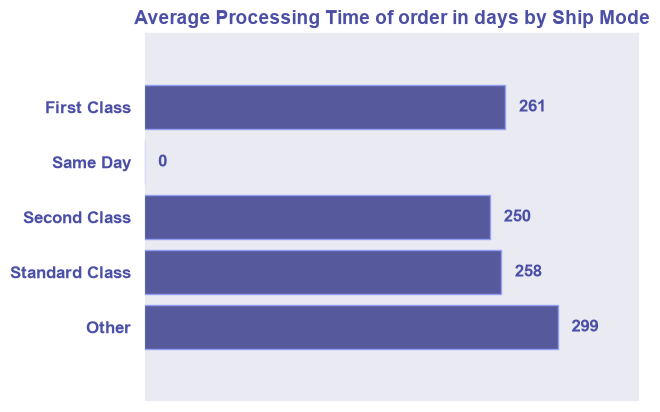

In [66]:
sns.set_theme()

ax = sns.barplot(
    data=avg_fulfillment_lag,
    x='order_processing_time_days',
    y='Ship Mode',
    color='#4B4FA6',
    edgecolor='#91A0F2',
    
)
ax.margins(x=0.2, y=0.2)
ax.grid(False)
ax.set_title('Average Processing Time of order in days by Ship Mode', fontsize=14, fontweight='bold', color='#4B4FA6')
ax.set_xlabel('')
ax.set_xticks([])
ax.set_xticklabels([])
ax.set_ylabel('')
ax.tick_params(axis='y', labelsize=12, labelcolor='#4B4FA6')
for label in ax.get_yticklabels():
    label.set_weight('bold')

for container in ax.containers:
    ax.bar_label(container, fontsize=12, fontweight='bold', color='#4B4FA6', padding=10)

In [68]:
# Business Question 12:
# What is the average fulfillment lag (days between Order Date and Ship Date) across different Ship Modes?

# Answer:
# First Class holds the highest average processing time with 261 days while Standard Class comes in 2nd with only 2days in difference.
# The longer processing time gets by Other kind of Ship Mode. Since its not defined, this means the customer set the condition for how they receive
# their orders.